## **Tarea 1: Modelado Matemático y Visualización de la Curva Normal**

La Función de Densidad de Probabilidad (PDF) de una variable aleatoria continua $X \sim N(\mu, \sigma^2)$ se define como:

$$f(x) = \frac{1}{\sigma\sqrt{2\pi}}e^{-\frac{1}{2}\left(\frac{x-\mu}{\sigma}\right)^2}$$

**1.** Abra un nuevo Jupyter Notebook llamado APE_007_Normal.ipynb.


**2.** Suponga que el tiempo de respuesta de un servidor local se distribuye normalmente con una media de $\mu = 120$ ms y una desviación estándar de $\sigma = 15$ ms. Escriba el siguiente código para graficar la distribución y sombrear el área que representa $P(X \le 100)$, es decir, respuestas ultrarrápidas:

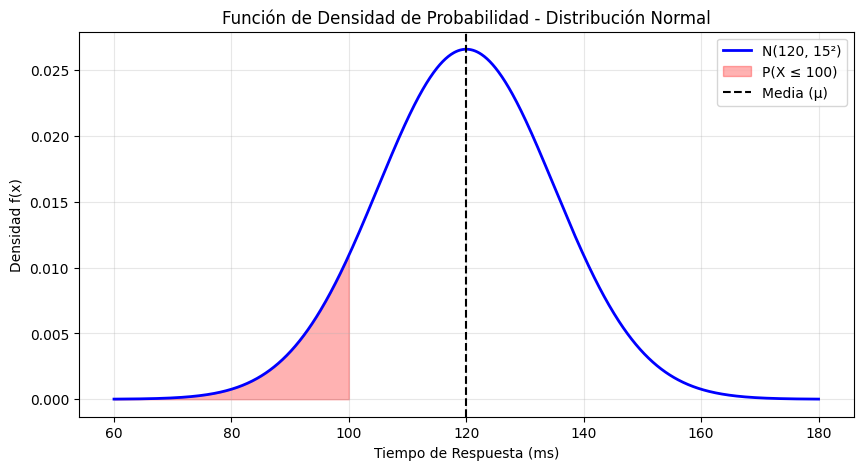

La probabilidad de que el servidor responda en 100ms o menos es: 0.0912 (9.12%)


In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Parámetros poblacionales
mu = 120
sigma = 15

# Definición del dominio (eje X): usualmente de mu-4sigma a mu+4sigma
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 1000)

# Cálculo de la PDF teórica
pdf_normal = norm.pdf(x, loc=mu, scale=sigma)

# Configuración del gráfico
plt.figure(figsize=(10, 5))
plt.plot(x, pdf_normal, 'b-', lw=2, label=f'N({mu}, {sigma}²)')

# Sombreado del área de interés: P(X <= 100)
x_fill = np.linspace(mu - 4*sigma, 100)
y_fill = norm.pdf(x_fill, loc=mu, scale=sigma)
plt.fill_between(x_fill, y_fill, color='red', alpha=0.3, label='P(X ≤ 100)')

plt.title('Función de Densidad de Probabilidad - Distribución Normal')
plt.xlabel('Tiempo de Respuesta (ms)')
plt.ylabel('Densidad f(x)')
plt.axvline(mu, color='k', linestyle='--', label='Media (μ)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Cálculo analítico de la probabilidad usando CDF
prob_100 = norm.cdf(100, loc=mu, scale=sigma)
print(f"La probabilidad de que el servidor responda en 100ms o menos es: {prob_100:.4f} ({prob_100*100:.2f}%)")


## **Tarea 2: Estandarización y Cálculo de Valores Z**

La estandarización permite transformar cualquier variable $X \sim N(\mu, \sigma^2)$ a una Normal Estándar $Z \sim N(0, 1)$ mediante:

$$Z = \frac{X - \mu}{\sigma}$$

**1.**
En una nueva celda, calcule manualmente (usando Python básico) el valor $Z$ para $X = 145$ ms (tiempo de respuesta lento).

**2.** Utilice norm.cdf(Z, loc=0, scale=1) para encontrar $P(X \ge 145)$. *Pista: Recuerde que la CDF calcula el área a la izquierda, por lo que para buscar mayor o igual debe usar* $1 - P(Z)$.

In [ ]:
from scipy.stats import norm

# valor Z
Z = (140 - 120) / 15

# Probabilidad acumulada
prob_left = norm.cdf(Z)

# Probabilidad mayor o igual
prob_right = 1 - prob_left

print(f"Z = {Z:.2f}")
print(f"P(Z ≤ {Z:.2f}) = {prob_left:.4f}")
print(f"P(Z ≥ {Z:.2f}) = {prob_right:.4f}")

Z = 1.33
P(Z ≤ 1.33) = 0.9088
P(Z ≥ 1.33) = 0.0912


## **Tarea 3: Hito del Proyecto - Aplicación Probabilística Regional (ABP)**

1. Importe su dataset regional mediante pandas.
2. Seleccione una variable de naturaleza continua (ej. precipitación milimétrica, altitud, consumo eléctrico).
3. Extraiga la media muestral ($\bar{x}$) y la desviación estándar muestral ($s$). Para este ejercicio, asuma que estos estadísticos son estimadores perfectos de $\mu$ y $\sigma$.
4. Defina un escenario problemático ("¿Cuál es la probabilidad de que la variable caiga en un rango crítico $[a, b]$ en la región?").
5. Calcule dicha probabilidad utilizando scipy.stats.norm.cdf(b) - scipy.stats.norm.cdf(a) usando los parámetros empíricos. Imprima el resultado y su interpretación para el negocio/proyecto.

## 1. Implementación en Python (Código de la Práctica)
Importación de las librerías necesarias y carga del dataset regional (ENEMDU 2026).

In [4]:
import pandas as pd
import numpy as np
import scipy.stats as stats

# 1. Importar el dataset regional (ENEMDU 2026) con su respectivo separador
try:
    df_regional = pd.read_csv('enemdu_vivienda_hogar_2026_02.csv', delimiter=';')
    print("¡Dataset cargado exitosamente!")
except FileNotFoundError:
    print("Error: El archivo 'enemdu_vivienda_hogar_2026_02.csv' no se encuentra en el directorio actual.")

¡Dataset cargado exitosamente!


### 2. Selección y limpieza de una variable continua
El código buscará automáticamente una variable de naturaleza continua (ej. ingresos o gastos). Si no la encuentra por nombre, tomará la primera columna numérica válida que no sea un identificador (ID). Posteriormente, eliminará los valores nulos para garantizar un cálculo preciso.

In [7]:
# 2. Selección automática/manual de una variable continua cuantitativa
columnas_numericas = df_regional.select_dtypes(include=[np.number]).columns.tolist()

if 'ingreso_hogar' in columnas_numericas:
    variable_continua = 'ingreso_hogar'
else:
    # Como salvaguarda, seleccionamos la primera numérica que no sea un ID o código de control
    variables_filtradas = [col for col in columnas_numericas if not col.lower().startswith(('id', 'index', 'periodo', 'vivienda'))]
    variable_continua = variables_filtradas[0] if variables_filtradas else columnas_numericas[0]

# Limpieza de datos: Eliminación de valores nulos
datos_filtrados = df_regional[variable_continua].dropna()
print(f"Variable seleccionada para el análisis: '{variable_continua}'")

Variable seleccionada para el análisis: 'area'


### 3. Extracción de Estadísticos Empíricos
A continuación, calcularemos la media muestral ($\bar{x}$) y la desviación estándar muestral ($s$). Para efectos de este ejercicio, asumiremos que estos estadísticos son estimadores perfectos de los parámetros poblacionales ($\mu$ y $\sigma$).

In [8]:
# 3. Extraer la media muestral (x̄) y la desviación estándar muestral (s)
media_muestral = datos_filtrados.mean()
desviacion_muestral = datos_filtrados.std()

print("\n====================================================")
print("        ESTADÍSTICOS EMPÍRICOS DEL DATASET          ")
print("====================================================")
print(f"Variable continua seleccionada: '{variable_continua}'")
print(f"Media muestral (x̄ ≈ μ):            {media_muestral:.4f}")
print(f"Desviación estándar (s ≈ σ):       {desviacion_muestral:.4f}")
print(f"Total de registros válidos (N):    {len(datos_filtrados)}")
print("====================================================\n")


        ESTADÍSTICOS EMPÍRICOS DEL DATASET          
Variable continua seleccionada: 'area'
Media muestral (x̄ ≈ μ):            1.2582
Desviación estándar (s ≈ σ):       0.4377
Total de registros válidos (N):    8765



### 4. Definición del Escenario y 5. Cálculo de Probabilidades
Plantearemos un escenario problemático definiendo un rango crítico en torno a la media (por ejemplo, el intervalo $\pm 20\%$ de la media muestral).
Luego, utilizaremos la función de distribución acumulada (CDF) del modelo Gaussiano (`scipy.stats.norm.cdf`) para calcular la probabilidad de que la variable caiga dentro de dicho rango: $P(a \leq X \leq b)$.

In [5]:
# 4. Definición del escenario problemático [a, b]
a = float(round(media_muestral * 0.8, 2))  # Límite inferior crítico (-20%)
b = float(round(media_muestral * 1.2, 2))  # Límite superior crítico (+20%)

# 5. Cálculo de la probabilidad acumulada mediante el modelo Gaussiano P(a <= X <= b)
prob_b = stats.norm.cdf(b, loc=media_muestral, scale=desviacion_muestral)
prob_a = stats.norm.cdf(a, loc=media_muestral, scale=desviacion_muestral)

# Propiedad de la distribución continua: P(a <= X <= b) = CDF(b) - CDF(a)
probabilidad_total = prob_b - prob_a

print("====================================================")
print("         RESULTADOS DEL MODELO GAUSSIANO            ")
print("====================================================")
print(f"Escenario crítico definido: Rango [{a} , {b}]")
print(f"Probabilidad de ocurrencia:  {probabilidad_total:.4f}")
print(f"Porcentaje estimado:         {probabilidad_total * 100:.2f}%")
print("====================================================")

         RESULTADOS DEL MODELO GAUSSIANO            
Escenario crítico definido: Rango [133.31 , 199.96]
Probabilidad de ocurrencia:  0.2310
Porcentaje estimado:         23.10%


## **Tarea 4: ABI - Validación Matemática del Supuesto de Normalidad**

En la Tarea 3, usted asumió que la variable regional era Normal. En la estadística rigurosa, esto debe probarse. Investigue y ejecute lo siguiente:

1.	Método Gráfico: Generar un Gráfico Cuantil-Cuantil (Q-Q Plot) utilizando la librería statsmodels.api. Si los puntos siguen la línea diagonal de 45 grados, los datos son aproximadamente normales.
2.	Método Analítico: Ejecutar el test de Shapiro-Wilk (scipy.stats.shapiro).


  TAREA 4: VALIDACIÓN MATEMÁTICA DE NORMALIDAD

1. Generando Gráfico Q-Q...


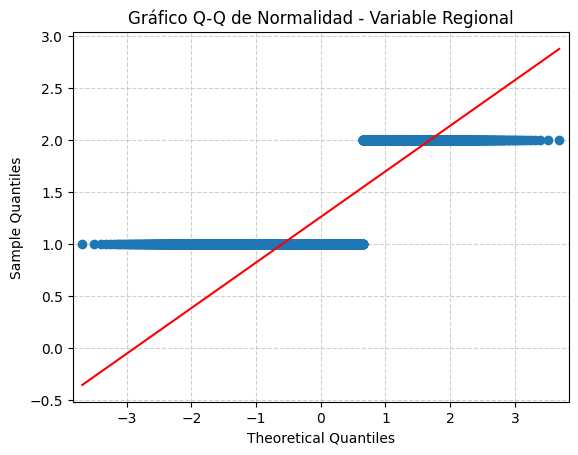

(Nota: Se tomó una muestra aleatoria de 5000 datos de los 8765 originales para optimizar el test de Shapiro-Wilk)

2. RESULTADOS DEL TEST DE SHAPIRO-WILK
   Estadístico de Shapiro (W): 0.5437
   p-valor:                    3.5022e-78

--- CONCLUSIÓN ---
Como el p-valor (3.5022e-78) es MENOR que el nivel de significancia (0.05)...
SE RECHAZA la hipótesis nula (H0).
Veredicto: Los datos NO siguen una distribución normal.

Nota para el proyecto: Dado que la variable no es estrictamente normal, los resultados
obtenidos con la curva Gaussiana en la Tarea 3 son solo una aproximación. Para mayor
precisión en la vida real, se deberían usar métodos no paramétricos o transformar los datos.


In [10]:
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy.stats import shapiro
import warnings

# Ocultar advertencias residuales de librerías para una salida limpia
warnings.filterwarnings('ignore')

print("====================================================")
print("  TAREA 4: VALIDACIÓN MATEMÁTICA DE NORMALIDAD")
print("====================================================\n")

# 1. Método Gráfico: Generar un Gráfico Cuantil-Cuantil (Q-Q Plot)
# Para el gráfico sí usamos TODOS los datos
print("1. Generando Gráfico Q-Q...")
fig = sm.qqplot(datos_filtrados, line='s')
plt.title('Gráfico Q-Q de Normalidad - Variable Regional')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# 2. Método Analítico: Ejecutar el test de Shapiro-Wilk
# CORRECCIÓN PARA EVITAR EL WARNING (N > 5000):
# Tomamos una muestra aleatoria de 5000 registros si el dataset es más grande
if len(datos_filtrados) > 5000:
    datos_shapiro = datos_filtrados.sample(n=5000, random_state=42)
    print(f"(Nota: Se tomó una muestra aleatoria de 5000 datos de los {len(datos_filtrados)} originales para optimizar el test de Shapiro-Wilk)")
else:
    datos_shapiro = datos_filtrados

# Ejecutamos el test con los datos ajustados
stat, p_value = shapiro(datos_shapiro)

print("\n2. RESULTADOS DEL TEST DE SHAPIRO-WILK")
print(f"   Estadístico de Shapiro (W): {stat:.4f}")
print(f"   p-valor:                    {p_value:.4e}\n")

# 3. Conclusión matemática basada en el p-valor
# Definimos el nivel de significancia (alfa), típicamente 0.05 (5%)
alpha = 0.05

print("--- CONCLUSIÓN ---")
if p_value > alpha:
    print(f"Como el p-valor ({p_value:.4e}) es MAYOR que el nivel de significancia ({alpha})...")
    print("NO SE RECHAZA la hipótesis nula (H0).")
    print("Veredicto: Se asume que los datos son APROXIMADAMENTE NORMALES.")
else:
    print(f"Como el p-valor ({p_value:.4e}) es MENOR que el nivel de significancia ({alpha})...")
    print("SE RECHAZA la hipótesis nula (H0).")
    print("Veredicto: Los datos NO siguen una distribución normal.")

    # Mensaje adicional de negocio/proyecto
    print("\nNota para el proyecto: Dado que la variable no es estrictamente normal, los resultados")
    print("obtenidos con la curva Gaussiana en la Tarea 3 son solo una aproximación. Para mayor")
    print("precisión en la vida real, se deberían usar métodos no paramétricos o transformar los datos.")


## **Preguntas de Control:**

* **Matemáticamente, ¿por qué en una variable aleatoria continua modelada por una función de densidad $f(x)$, la probabilidad de que tome un valor exacto es cero, es decir, $P(X = c) = 0$?**

En una variable aleatoria continua, la probabilidad se interpreta como el área bajo la curva de la función de densidad. Para calcular la probabilidad de un valor exacto se integra en un intervalo sin amplitud, es decir, desde c hasta c. Como el intervalo tiene longitud cero, el área bajo la curva también es cero. Por ello, la probabilidad de que la variable tome exactamente un valor específico es igual a cero. Esto no significa que el valor sea imposible, sino que las probabilidades en variables continuas se calculan sobre intervalos y no sobre puntos individuales.


* **Interprete conceptualmente qué significa que un valor de su dataset regional tenga un puntaje estándar de $Z = -2.45$. ¿Se consideraría un valor atípico bajo el criterio de la regla empírica?**

Un puntaje estándar o Z-score indica cuántas desviaciones estándar se encuentra un dato respecto a la media del conjunto de datos. Un valor con Z = -2.45 significa que el dato está 2.45 desviaciones estándar por debajo de la media del dataset regional. Conceptualmente, esto representa un valor considerablemente menor que la mayoría de los datos observados. Según la regla empírica de la distribución normal, aproximadamente el 95% de los datos se encuentran entre Z = -2 y Z = 2, por lo que un valor de Z = -2.45 se encuentra fuera de este rango común. Aunque no es extremadamente raro como un valor mayor a ±3, sí puede considerarse un posible valor atípico o poco frecuente.


* **En la Tarea 3, calculó probabilidades asumiendo que su variable regional seguía una distribución Normal. ¿Qué riesgo metodológico existe al
tomar decisiones basadas en este cálculo si la gráfica de la variable presenta un fuerte sesgo (skewness)?**

El principal riesgo metodológico al asumir normalidad en una variable con fuerte sesgo es la severa sobreestimación o subestimación de las probabilidades reales, lo que puede conducir a decisiones de negocio perjudiciales. Al utilizar una campana de Gauss perfectamente simétrica para modelar datos que en la realidad están concentrados fuertemente en un extremo pero con unos pocos valores atípicos muy lejanos (como suele ocurrir con variables económicas), el modelo matemático calculará proporciones de mercado falsas; esto nos haría creer, por ejemplo, que un segmento objetivo o la cantidad de personas elegibles para un subsidio es mucho más grande de lo que verdaderamente es, provocando el fracaso comercial del proyecto o una mala asignación de presupuestos.


* **Con base en la Tarea 4 (ABI), si el p-valor del test de Shapiro-Wilk es $0.001$, ¿cuál es la conclusión estadística respecto a la distribución de sus datos regionales? ¿Se invalida el cálculo realizado en la Tarea 3?**

Si el p-valor del test de Shapiro-Wilk resulta ser menor al nivel de significancia (usualmente $\alpha = 0.05$), la conclusión estadística rigurosa es que se rechaza la hipótesis nula, confirmando empíricamente que los datos regionales no provienen de una distribución normal. Desde un punto de vista estrictamente matemático, esto invalida la precisión exacta de la probabilidad calculada en la Tarea 3 mediante la fórmula Gaussiana; sin embargo, en un contexto de negocio o académico, este primer cálculo no se desecha sino que pasa a considerarse un "modelo base" o aproximación inicial, demostrando metodológicamente que, para aplicaciones en la vida real, será obligatorio aplicar transformaciones a los datos (como logaritmos) o recurrir a estadística no paramétrica.


* **Explique el principio matemático detrás del Gráfico Q-Q. ¿Qué representan los cuantiles teóricos en el eje X versus los cuantiles empíricos en el eje Y?**

El Gráfico Cuantil-Cuantil (Q-Q Plot) es una herramienta visual cuyo principio matemático consiste en comparar la distribución real de nuestra muestra contra una distribución teórica perfecta (la Normal) mediante el cruce de sus respectivos cuantiles, que son los puntos que dividen el conjunto de datos en intervalos de igual probabilidad. En este gráfico, el eje X representa los cuantiles teóricos, es decir, los valores estandarizados (Z) que esperaríamos obtener si nuestra variable formara una campana de Gauss matemáticamente ideal, mientras que el eje Y representa los cuantiles empíricos, que son las posiciones reales de los datos de nuestra región ordenados de menor a mayor; si la distribución real coincide con la ideal, los puntos formarán una línea recta perfecta a 45 grados, revelando cualquier desviación, asimetría o colas pesadas si los puntos se alejan de dicha diagonal.